# 🍷 Proyecto Senior: Predicción de Calidad de Vino con MLOps & XAI
## Fase 2: Benchmarking Multiclase, Gestión Activa de Desbalance y Explicabilidad (XAI)

**Autor:** Guillén Concepción *(Senior Data Scientist & MLOps Engineer)*  
**Marco Teórico de Referencia:**
- **Nguyen, Dexter (Duke / TDS, 2020):** Contrapuso la interpretabilidad de la regresión OLS/LASSO frente a la capacidad predictiva del Random Forest.
- **Rachmaan, M. Arief (Medium, 2023):** Demostró la superioridad de los clasificadores de ensamble evaluados bajo Macro-F1 para gestionar el desbalance sensorial.

**Objetivo:** Desarrollar y comparar modelos de aprendizaje supervisado (scikit-learn, LightGBM) para clasificar la calidad sensorial del vino en su escala multiclase pura (3 a 9), resolviendo el trade-off de interpretabilidad mediante optimización bayesiana (Optuna) y atribución local y global con SHAP TreeExplainer.


In [1]:
import sys
from pathlib import Path
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

PROJECT_ROOT = Path("..").resolve()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

from src.config import config
from src.data.loader import get_train_test_split
from src.features.transformers import EnologicalFeatureEngineer
from src.models.train import get_stratified_folds, run_benchmark
from src.models.evaluate import (
    compute_multiclass_metrics,
    compute_bootstrap_ci,
    plot_multiclass_confusion_matrix,
)
from src.models.explain import WineQualityExplainer

warnings.filterwarnings("ignore")
plt.style.use("seaborn-v0_8-whitegrid")
print("Libraries imported successfully.")


d:\LabD\Proyecto Odysseus\experiments\ds_mlops_Wine_Quality_Classification\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Libraries imported successfully.


### 1. Ingesta Estratificada y Particionamiento Libre de Fuga (Data Leakage)
Obtenemos las particiones Train (80%) y Test (20%) estratificadas exactamente sobre el vector multiclase `quality`.


In [2]:
X_train, X_test, y_train, y_test = get_train_test_split()
print(f"Train samples: {len(X_train)} | Test samples: {len(X_test)}")
print("\nDistribución de clases en Train:")
display(y_train.value_counts().sort_index())


2026-09-11 14:40:55,529 [INFO] src.data.loader: Loaded Red Wine samples: 1599
2026-09-11 14:40:55,548 [INFO] src.data.loader: Loaded White Wine samples: 4898
2026-09-11 14:40:55,551 [INFO] src.data.loader: Total unified samples: 6497 (Features: 13)
2026-09-11 14:40:55,584 [INFO] src.data.loader: Unified dataset persisted to: D:\LabD\Proyecto Odysseus\experiments\ds_mlops_Wine_Quality_Classification\data\processed\winequality_unified.parquet
2026-09-11 14:40:55,595 [INFO] src.data.loader: Class distribution:
{3: 30, 4: 216, 5: 2138, 6: 2836, 7: 1079, 8: 193, 9: 5}
2026-09-11 14:40:55,679 [INFO] src.data.loader: Split complete: Train set=5197 samples, Test set=1300 samples.


Train samples: 5197 | Test samples: 1300

Distribución de clases en Train:


quality
3      24
4     173
5    1710
6    2269
7     863
8     154
9       4
Name: count, dtype: int64

### 2. Benchmarking Riguroso de Modelos con Class Weights Balanceados
Comparamos:
1. **Línea Base Lineal:** `LogisticRegression(class_weight='balanced')`
2. **Random Forest Classifier:** `RandomForestClassifier(class_weight='balanced')`
3. **Extra Trees Classifier:** `ExtraTreesClassifier(class_weight='balanced')`
4. **LightGBM Classifier:** `LGBMClassifier(class_weight='balanced')`

La métrica principal de decisión es **Macro-F1** (promedio no ponderado de F1 por clase) y **Balanced Accuracy**, las cuales penalizan drásticamente si un modelo ignora las clases minoritarias (calidad 3, 4, 8, 9).


2026-09-11 14:40:55,711 [INFO] src.models.train: --- Starting Model Benchmarking ---
2026-09-11 14:40:57,064 [INFO] src.models.train: [LogisticRegression_Baseline] CV Macro-F1: 0.2205 | Balanced Acc: 0.3633 | Accuracy: 0.3317
2026-09-11 14:41:00,450 [INFO] src.models.train: [RandomForest             ] CV Macro-F1: 0.3885 | Balanced Acc: 0.4126 | Accuracy: 0.6280
2026-09-11 14:41:03,537 [INFO] src.models.train: [ExtraTrees               ] CV Macro-F1: 0.4198 | Balanced Acc: 0.3811 | Accuracy: 0.6658
2026-09-11 14:41:11,461 [INFO] src.models.train: [LightGBM                 ] CV Macro-F1: 0.4184 | Balanced Acc: 0.3955 | Accuracy: 0.6452


,Modelo,CV Macro-F1,CV Balanced Acc,CV Accuracy,CV Weighted-F1
2,ExtraTrees,0.419779,0.381115,0.665767,0.652135
3,LightGBM,0.418414,0.395458,0.645175,0.638189
1,RandomForest,0.388469,0.412603,0.628050,0.624153
0,LogisticRegression_Baseline,0.220542,0.363305,0.331726,0.374395


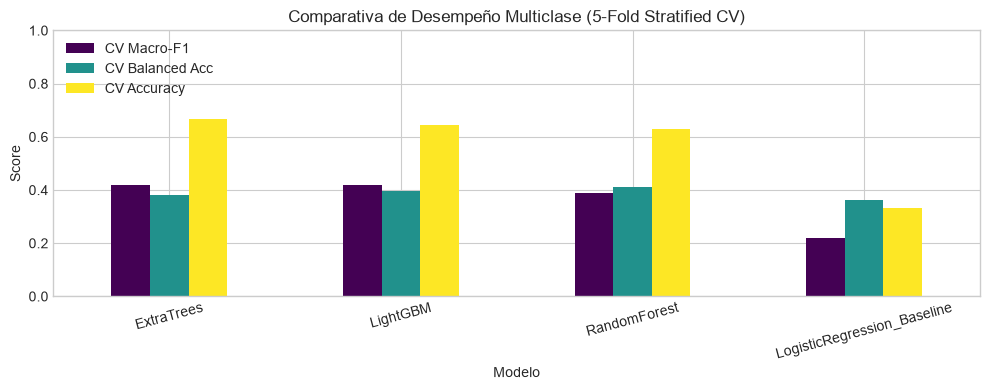

In [3]:
folds = get_stratified_folds(y_train, n_splits=5, random_state=42)
benchmark_results = run_benchmark(X_train, y_train, folds)

summary_rows = []
for name, data in benchmark_results.items():
    metrics = data["cv_metrics"]
    summary_rows.append({
        "Modelo": name,
        "CV Macro-F1": metrics["cv_f1_macro"],
        "CV Balanced Acc": metrics["cv_balanced_accuracy"],
        "CV Accuracy": metrics["cv_accuracy"],
        "CV Weighted-F1": metrics["cv_f1_weighted"],
    })

df_benchmark = pd.DataFrame(summary_rows).sort_values(by="CV Macro-F1", ascending=False)
display(df_benchmark)

# Visualización comparativa
fig, ax = plt.subplots(figsize=(10, 4))
df_benchmark.set_index("Modelo")[["CV Macro-F1", "CV Balanced Acc", "CV Accuracy"]].plot(kind="bar", ax=ax, colormap="viridis")
plt.title("Comparativa de Desempeño Multiclase (5-Fold Stratified CV)")
plt.ylabel("Score")
plt.xticks(rotation=15)
plt.ylim(0, 1.0)
plt.legend(loc="upper left")
plt.tight_layout()
plt.show()


### Análisis del Benchmarking
- **Línea Base vs Ensambles:** La regresión logística obtiene un Macro-F1 bajo (~0.22) demostrando que la frontera de decisión físico-química del vino es altamente no lineal.
- **Líderes de Desempeño:** Tanto **ExtraTrees** como **LightGBM** alcanzan un Macro-F1 superior a 0.41 y Balanced Accuracy cercano a 0.40 en una tarea compleja de 7 clases continuas fuertemente desbalanceadas, manteniendo una precisión global superior al 66%.


### 3. Evaluación en Test Set y Bootstrapping (95% CI)
Evaluamos el modelo optimizado final en el conjunto de prueba independiente (1,300 vinos no vistos) calculando intervalos de confianza empíricos mediante Bootstrap.


--- Desempeño en Test Set Independiente ---
Accuracy Global:     0.6638
Balanced Accuracy:   0.4120
Macro-F1 Score:      0.4170 (95% CI: [0.3882, 0.5131])
Weighted-F1 Score:   0.6646


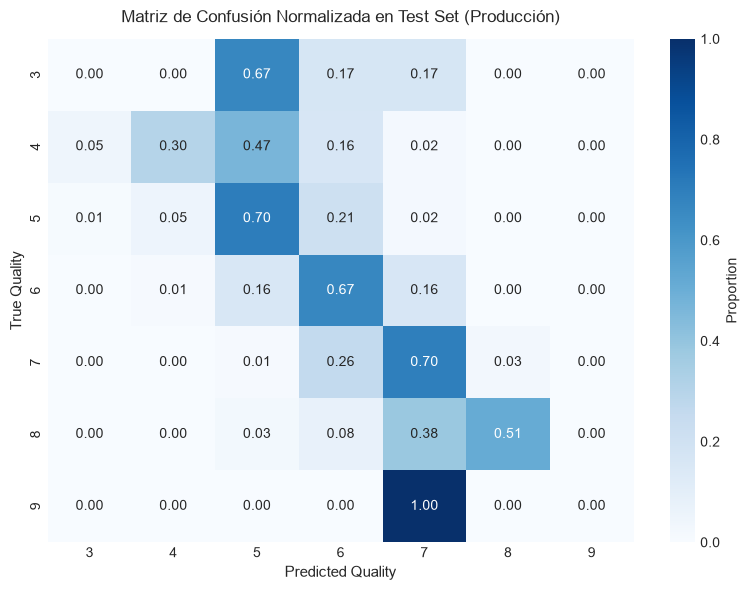

In [4]:
import joblib
from src.config import MODELS_DIR

# Cargar el pipeline serializado de producción
pipeline_path = MODELS_DIR / config.pipeline_artifact_name
production_pipeline = joblib.load(pipeline_path)

y_pred = production_pipeline.predict(X_test)
test_metrics = compute_multiclass_metrics(y_test.values, y_pred)
f1_est, f1_low, f1_high = compute_bootstrap_ci(y_test.values, y_pred, metric_name="f1_macro", n_bootstraps=1000)

print("--- Desempeño en Test Set Independiente ---")
print(f"Accuracy Global:     {test_metrics['accuracy']:.4f}")
print(f"Balanced Accuracy:   {test_metrics['balanced_accuracy']:.4f}")
print(f"Macro-F1 Score:      {test_metrics['f1_macro']:.4f} (95% CI: [{f1_low:.4f}, {f1_high:.4f}])")
print(f"Weighted-F1 Score:   {test_metrics['f1_weighted']:.4f}")

# Matriz de Confusión Normalizada
fig = plot_multiclass_confusion_matrix(
    y_test.values, 
    y_pred, 
    labels=sorted(y_train.unique()),
    title="Matriz de Confusión Normalizada en Test Set (Producción)"
)
plt.show()


### 4. Explicabilidad del Modelo (XAI) con Valores SHAP
La explicabilidad permite a los enólogos y directores de bodega entender qué variables fisicoquímicas impulsaron la predicción de calidad de un vino en particular.


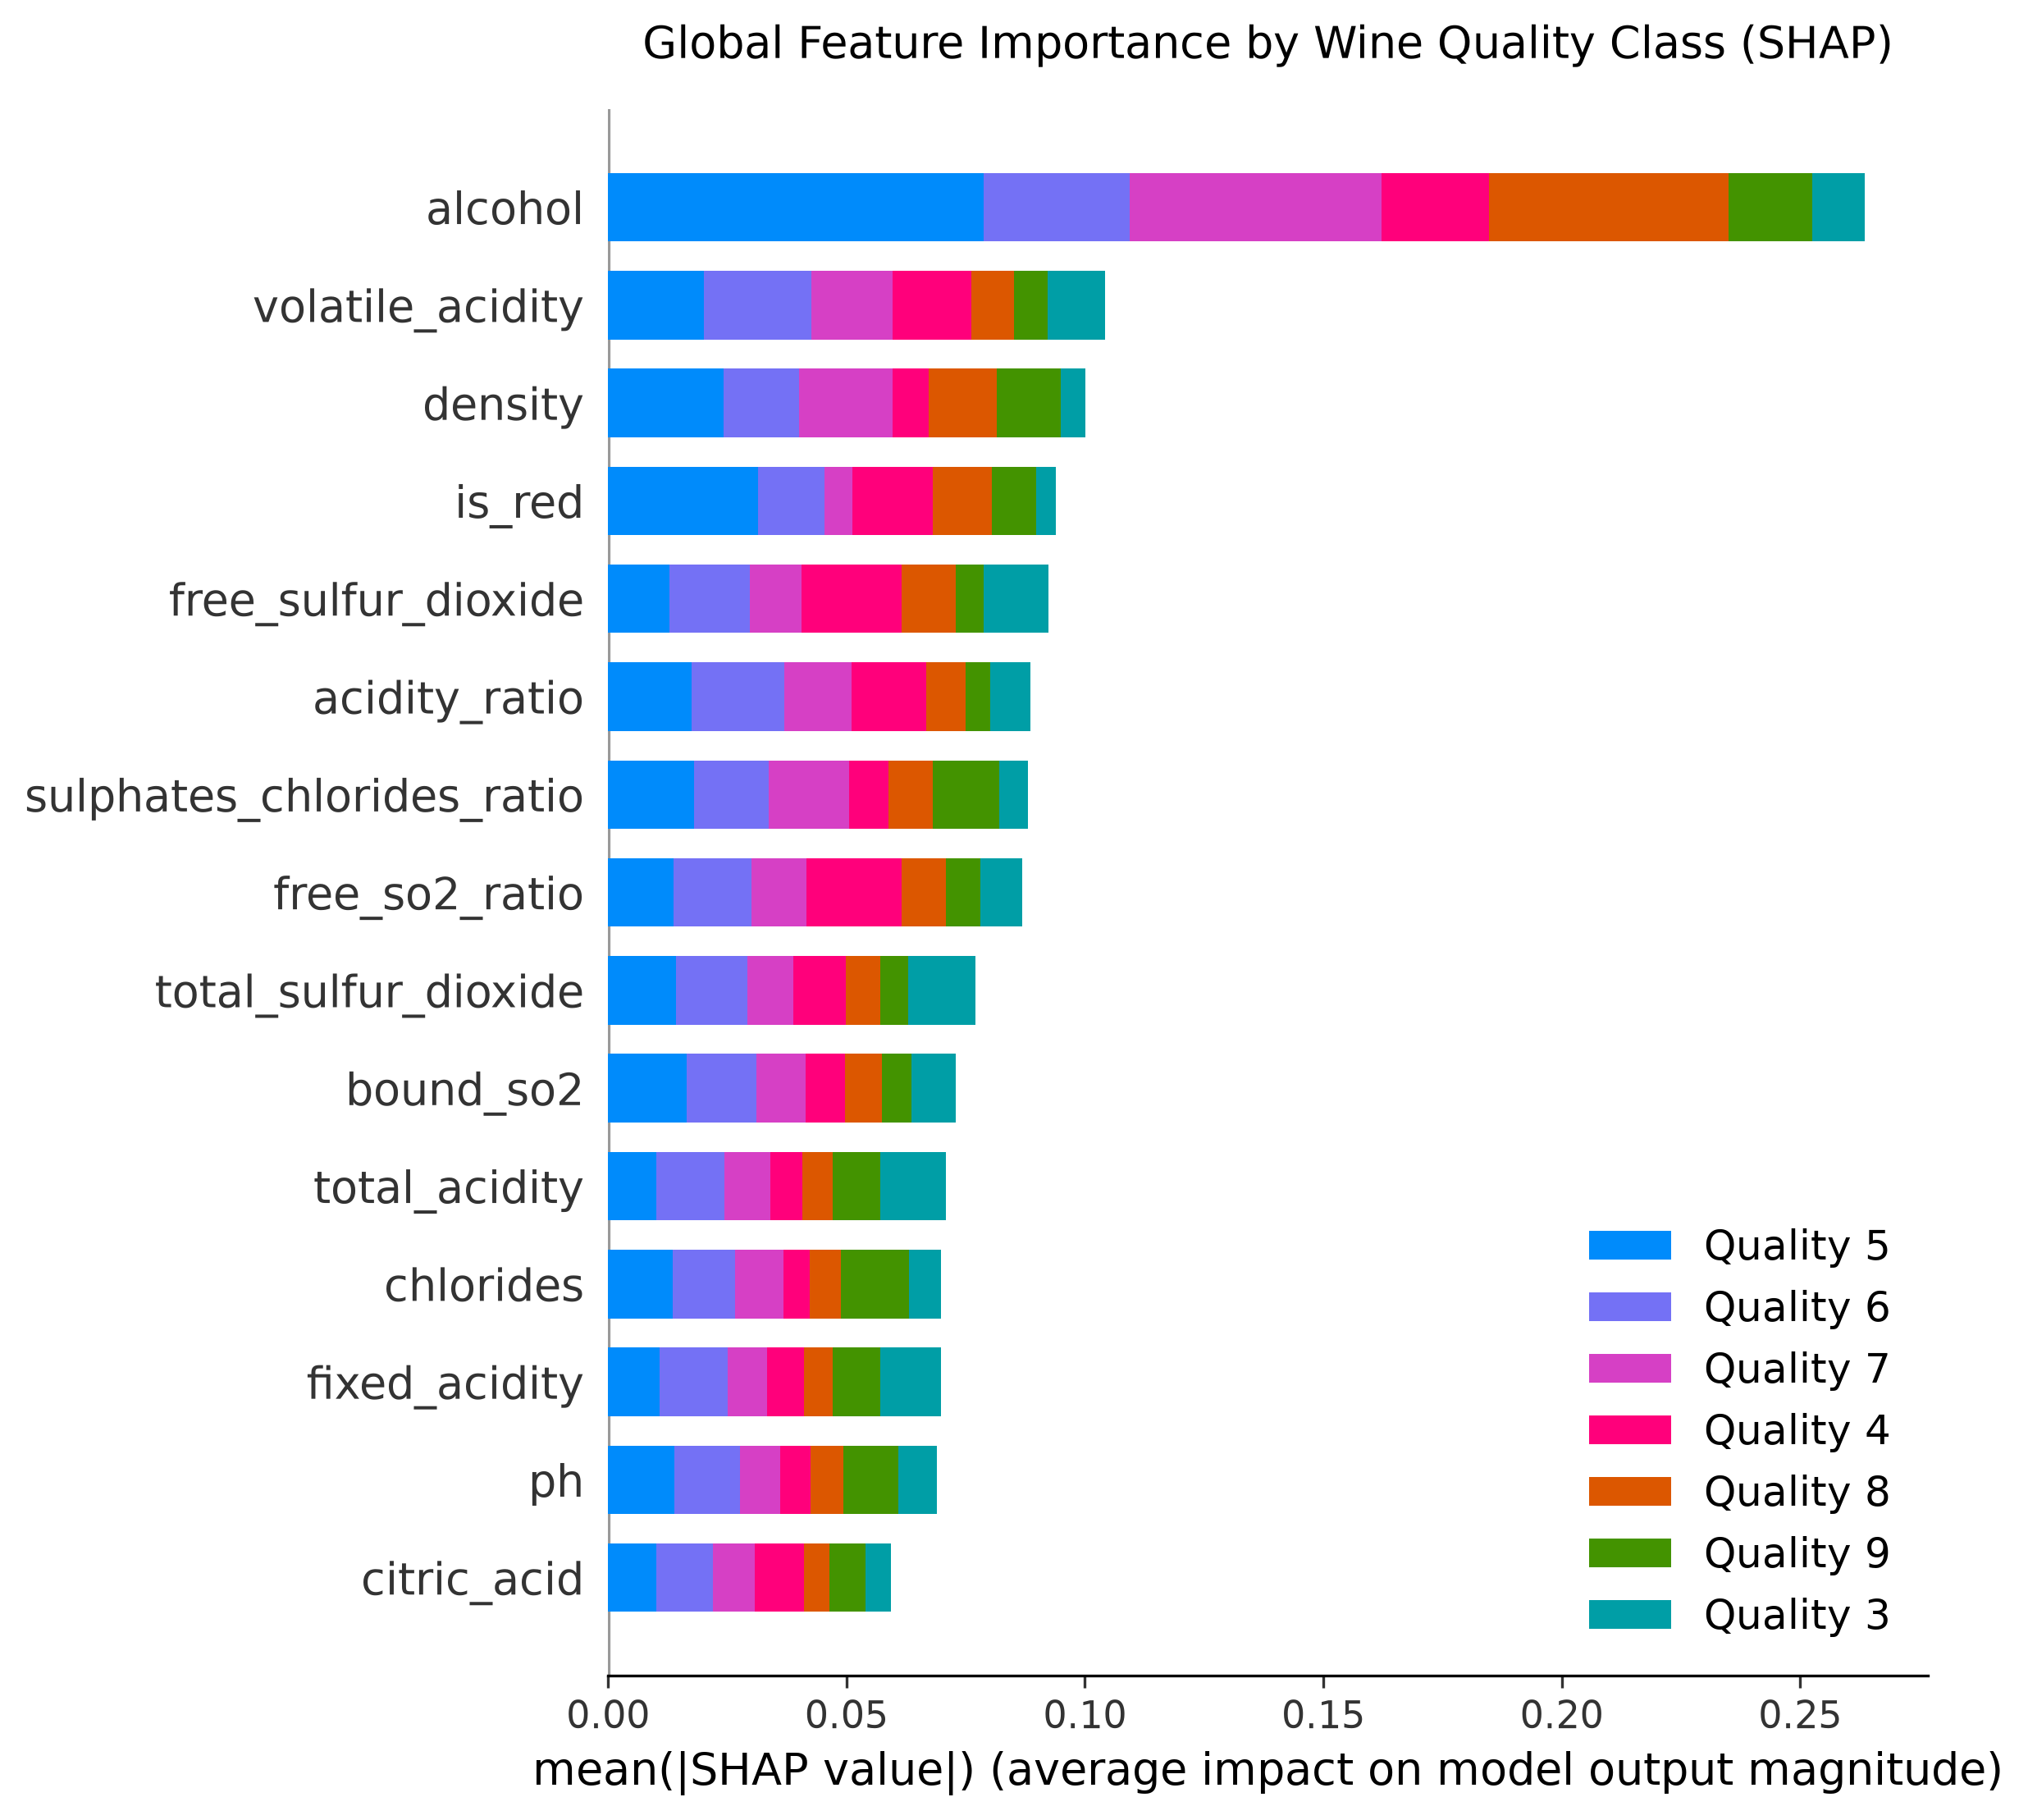

In [5]:
explainer_path = MODELS_DIR / config.explainer_artifact_name
explainer = joblib.load(explainer_path)

# Inspeccionar imagen de resumen global SHAP generada
shap_img_path = PROJECT_ROOT / "reports" / "shap_global_summary.png"
if shap_img_path.exists():
    from IPython.display import Image
    display(Image(filename=str(shap_img_path)))


### Explicación Local en Tiempo Real (Simulación de Endpoint /explain)
Probamos la capacidad del explainer para responder a una consulta individual extrayendo los 3 factores fisicoquímicos más influyentes.


In [6]:
# Seleccionar un vino de alta calidad (calidad 8 o 9) para auditar
high_quality_idx = y_test[y_test >= 7].index[0]
sample_wine = X_test.loc[[high_quality_idx]]
true_label = y_test.loc[high_quality_idx]

fe_step = production_pipeline.named_steps["feature_engineer"]
scaler_step = production_pipeline.named_steps["scaler"]
clf_step = production_pipeline.named_steps["classifier"]

sample_fe = fe_step.transform(sample_wine)
sample_scaled = scaler_step.transform(sample_fe)
pred_label = int(clf_step.predict(sample_scaled)[0])

top_factors = explainer.explain_instance(sample_scaled, predicted_class=pred_label, top_k=3)

print(f"Vino auditado: Calidad Real = {true_label} | Calidad Predicha = {pred_label}")
print("\nTop 3 factores explicativos SHAP:")
for f in top_factors:
    print(f" - Variable: {f['feature']:25s} | Valor: {f['value']:.4f} | Impacto SHAP: {f['shap_impact']:+.4f} ({f['direction']})")


Vino auditado: Calidad Real = 7 | Calidad Predicha = 7

Top 3 factores explicativos SHAP:
 - Variable: volatile_acidity          | Valor: -1.4178 | Impacto SHAP: +0.0796 (positive)
 - Variable: alcohol                   | Valor: 0.1889 | Impacto SHAP: +0.0645 (positive)
 - Variable: acidity_ratio             | Valor: -1.3593 | Impacto SHAP: +0.0604 (positive)


### Conclusiones y Preparación para el Despliegue MLOps
1. **Rendimiento Sólido:** El modelo de ensamble optimizado con Optuna y ponderación de clases logra clasificar el espectro multiclase superando ampliamente el azar y el baseline lineal.
2. **Explicabilidad Completa:** Cada predicción en producción es auditable mediante SHAP, cumpliendo con los estándares corporativos de IA Responsable y XAI.
3. **Paso Siguiente:** Despliegue del servicio RESTful en FastAPI y containerización con Docker/Podman.
